In [2]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
%autoreload 2
# import libraries
import glob
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import matplotlib.patches as patches

import nibabel as nib
from nibabel.affines import apply_affine

import xarray as xr

In [4]:
np.set_printoptions(suppress=True, precision=4)  # suppresses scientific notation

## Resources for this notebook:
- https://lukas-snoek.com/NI-edu/fMRI-introduction/week_1/python_for_mri.html
- https://nipy.org/nibabel/
- https://nipy.org/nibabel/coordinate_systems.html
- https://textbook.nipraxis.org/nibabel_apply_affine.html

## Lazy load data

In [108]:
mri_path = "../data/Johnson_etal_2019_Canine_Atlas_v2/"
atlas_file = 'whole_atlas_cortical_subcortical.nii.gz'
#mri_file = 'Canine_population_template.nii.gz'
img = nib.load(mri_path + atlas_file)  # this is a lazy load like in xarray, load the data to memory with img.get_fdata()

In [109]:
print(type(img))

<class 'nibabel.nifti1.Nifti1Image'>


## Check metadata

In [110]:
print(img)


<class 'nibabel.nifti1.Nifti1Image'>
data shape (124, 120, 200)
affine:
[[  0.4995   0.0187  -0.0072 -30.2075]
 [  0.0083  -0.0156   0.4685 -50.8231]
 [ -0.0197   0.4682   0.0159 -17.4854]
 [  0.       0.       0.       1.    ]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'')
extents         : 0
session_error   : 0
regular         : np.bytes_(b'r')
dim_info        : 0
dim             : [  3 124 120 200   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [-1.      0.4999  0.4688  0.4688  0.      0.      0.      0.    ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax   

In [111]:
print(img.shape)

(124, 120, 200)


In [114]:
# get header of MRI
header = img.header

# print voxel size
print(f"voxel size: {header.get_zooms()}")

# the units of the measurements (here: voxel size in millimeter and time in seconds)
print(f"unit of measurements: {header.get_xyzt_units()}")

voxel size: (np.float32(0.49994278), np.float32(0.4688), np.float32(0.4688))
unit of measurements: ('mm', 'sec')


## Data visualisation

In [116]:
img_data = img.get_fdata() # data loaded into memory as numpy array
print(img_data.shape)
print(img_data.max())
print(img_data.min())

(124, 120, 200)
451.0
0.0


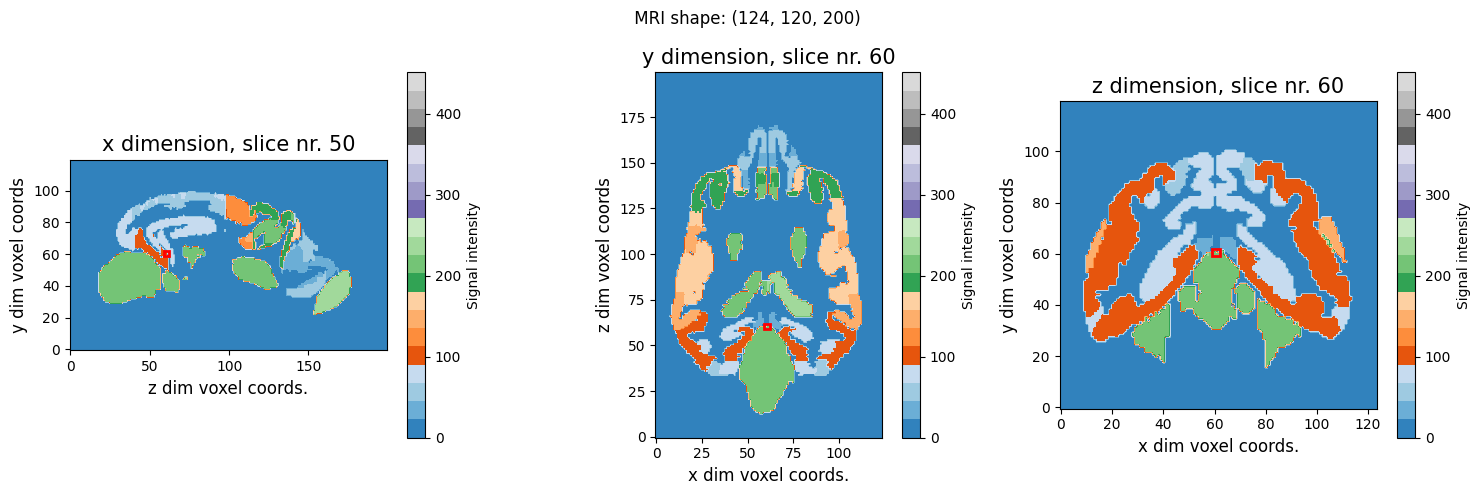

In [118]:
fig, ax = plt.subplots(ncols=3, figsize=(15, 5))

im0 = ax[0].imshow(img_data[49, :, :], origin='lower', cmap='tab20c', vmin=img_data.min(), vmax=img_data.max())
ax[0].set_xlabel('z dim voxel coords.', fontsize=12)
ax[0].set_ylabel('y dim voxel coords', fontsize=12)
ax[0].set_title('x dimension, slice nr. 50', fontsize=15)
rect = patches.Rectangle((59, 59), 3, 3, linewidth=2, edgecolor='r', facecolor='none')
ax[0].add_patch(rect)
fig.colorbar(im0, ax=ax[0], label='Signal intensity')

im1 = ax[1].imshow(img_data[:, 59, :].T, origin='lower', cmap='tab20c', vmin=img_data.min(), vmax=img_data.max())
ax[1].set_xlabel('x dim voxel coords.', fontsize=12)
ax[1].set_ylabel('z dim voxel coords', fontsize=12)
ax[1].set_title('y dimension, slice nr. 60', fontsize=15)
rect = patches.Rectangle((59, 59), 3, 3, linewidth=2, edgecolor='r', facecolor='none')
ax[1].add_patch(rect)
fig.colorbar(im1, ax=ax[1], label='Signal intensity')

im2 = ax[2].imshow(img_data[:, :, 59].T, origin='lower', cmap='tab20c', vmin=img_data.min(), vmax=img_data.max())
ax[2].set_xlabel('x dim voxel coords.', fontsize=12)
ax[2].set_ylabel('y dim voxel coords', fontsize=12)
ax[2].set_title('z dimension, slice nr. 60', fontsize=15)
rect = patches.Rectangle((59, 59), 3, 3, linewidth=2, edgecolor='r', facecolor='none')
ax[2].add_patch(rect)
fig.colorbar(im2, ax=ax[2], label='Signal intensity')

plt.suptitle(f" MRI shape: {img_data.shape}")

fig.tight_layout()

## Convert MRI to xarray.DataArray with voxel coordinates

In [119]:
print(img)


<class 'nibabel.nifti1.Nifti1Image'>
data shape (124, 120, 200)
affine:
[[  0.4995   0.0187  -0.0072 -30.2075]
 [  0.0083  -0.0156   0.4685 -50.8231]
 [ -0.0197   0.4682   0.0159 -17.4854]
 [  0.       0.       0.       1.    ]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'')
extents         : 0
session_error   : 0
regular         : np.bytes_(b'r')
dim_info        : 0
dim             : [  3 124 120 200   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [-1.      0.4999  0.4688  0.4688  0.      0.      0.      0.    ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax   

In [120]:
# get affine from MRI image
A = img.affine
print('Affine matrix:')
print(A)
print(' ')
print(f"voxel_size:{ header.get_zooms()}")

Affine matrix:
[[  0.4995   0.0187  -0.0072 -30.2075]
 [  0.0083  -0.0156   0.4685 -50.8231]
 [ -0.0197   0.4682   0.0159 -17.4854]
 [  0.       0.       0.       1.    ]]
 
voxel_size:(np.float32(0.49994278), np.float32(0.4688), np.float32(0.4688))


In [121]:
# convert coordinates into mm
new_x = np.zeros((img.shape[0]))
new_y = np.zeros((img.shape[2]))
new_z = np.zeros((img.shape[1]))

for x in range(0, img.shape[0]):
    for y in range(0, img.shape[2]):
        for z in range(0, img.shape[1]):
            new_x[x] = apply_affine(img.affine, [x,y,z])[0]
            new_y[y] = apply_affine(img.affine, [x,y,z])[2]
            new_z[z] = apply_affine(img.affine, [x,y,z])[1]

In [122]:
apply_affine(img.affine, [x,y,z])

array([34.1033,  2.8427, 75.1481])

In [123]:
# check voxel size is ok
np.diff(new_y)

array([0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682,
       0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682,
       0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682,
       0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682,
       0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682,
       0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682,
       0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682,
       0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682,
       0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682,
       0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682,
       0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682,
       0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682,
       0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682,
       0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682, 0.4682,
      

In [124]:
ds = xr.Dataset(
    data_vars=dict(
        mri=(["x", "z", "y"], img_data),
    ),
    coords={'x':new_x, 'y':new_y, 'z':new_z},
    attrs=dict(affine=img.affine.flatten(), 
               voxel_size_x=header.get_zooms()[0], voxel_size_y=header.get_zooms()[1], voxel_size_z = header.get_zooms()[2], 
               voxel_size_unit= header.get_xyzt_units()[0], file_name = mri_file, file_rel_path = mri_path
               )
               )

# reorder dimensions
ds = ds.transpose("x", "y", "z")

# add attributes
ds['x'].attrs = {'name': 'x dimension', "units": "mm", }
ds['y'].attrs = {'name': 'y dimension', "units": "mm", }
ds['z'].attrs = {'name': 'z dimension', "units": "mm", }
ds['mri'].attrs = {'name': 'signal intensity' }

# save as netcdf
ds.to_netcdf(path= mri_path + mri_file.split('.')[0]+'.nc')
ds

<xarray.Dataset> Size: 24MB
Dimensions:  (x: 124, z: 120, y: 200)
Coordinates:
  * x        (x) float64 992B -27.33 -26.83 -26.33 -25.83 ... 33.1 33.6 34.1
  * y        (y) float64 2kB -18.02 -17.55 -17.08 -16.61 ... 74.21 74.68 75.15
  * z        (z) float64 960B -52.91 -52.44 -51.97 -51.5 ... 1.906 2.374 2.843
Data variables:
    mri      (x, y, z) float64 24MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Attributes:
    affine:           [  0.4995   0.0187  -0.0072 -30.2075   0.0083  -0.0156 ...
    voxel_size_x:     0.49994278
    voxel_size_y:     0.4688
    voxel_size_z:     0.4688
    voxel_size_unit:  mm
    file_name:        Canine_population_template.nii.gz
    file_rel_path:    ../data/Johnson_etal_2019_Canine_Atlas_v2/

In [126]:
def plot_slice(mri_slice, x, y):
    plt.figure(dpi=100)
    mri_slice.plot(x=x, y=y, cmap='tab20c', vmin=0, vmax=255)
    plt.plot(0, 0, 'ro')

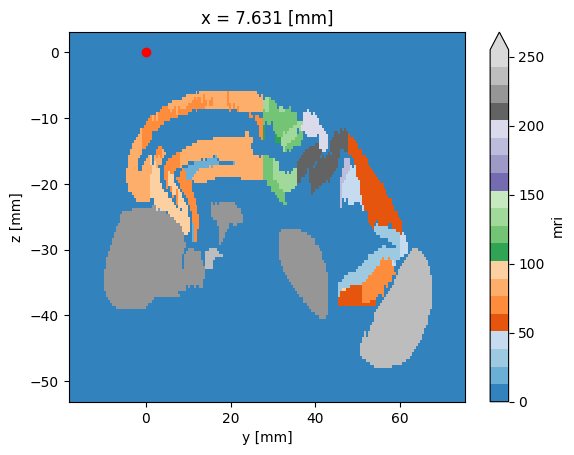

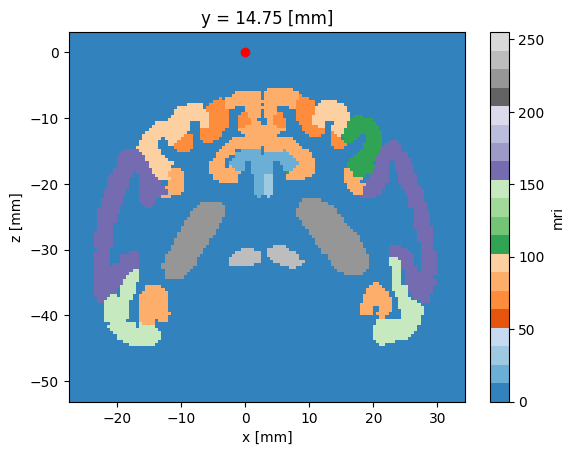

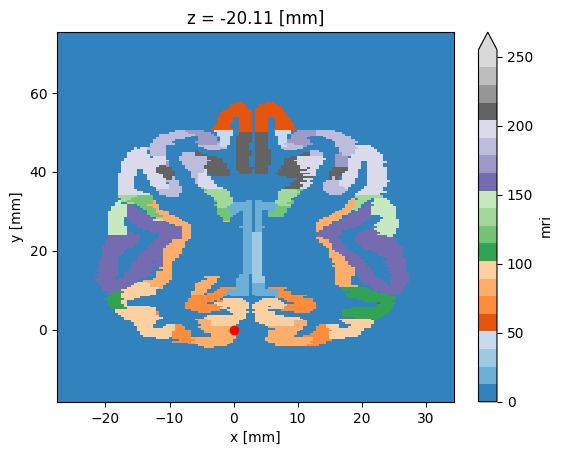

In [127]:
plot_slice(ds.mri.isel(x=70), x='y', y='z')
plot_slice(ds.mri.isel(y=70), x='x', y='z')
plot_slice(ds.mri.isel(z=70), x='x', y='y')